In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [281]:

columns=['_STATE','_AGE_G','_SEX','_INCOMG','_IMPRACE','_URBSTAT','_EDUCAG','VETERAN3','EMPLOY1','MEDCOST','_SMOKER3','USENOW3','SMOKE100'
         ,'DIABETE4','_BMI5CAT','CHCCOPD2','FLUSHOT7','_LLCPWT','GENHLTH','PERSDOC2','CHECKUP1','CVDCRHD4','CVDSTRK3','CVDINFR4','TOLDHI2'
         ,'MENTHLTH','PHYSHLTH','POORHLTH','ADDEPEV3','HAVARTH4','PNEUVAC4','ASTHMA3','ASTHNOW','CHCKDNY2']
brfss_2019=pd.read_sas(r"E:\ibm machine learning\python_files\LLCP2019.XPT")
brfss_2019=brfss_2019[columns]
brfss_2019.columns=brfss_2019.columns.str.replace('_','')

categorical_vars = [
    'AGEG','SEX','INCOMG','IMPRACE','URBSTAT','EDUCAG','VETERAN3','EMPLOY1',
    'MEDCOST','SMOKER3','USENOW3','SMOKE100','DIABETE4','BMI5CAT','CHCCOPD2',
    'FLUSHOT7','GENHLTH','PERSDOC2','CHECKUP1','CVDCRHD4','CVDSTRK3','CVDINFR4',
    'TOLDHI2','ADDEPEV3','HAVARTH4',
    'PNEUVAC4','ASTHMA3','ASTHNOW','CHCKDNY2']

# Replace 7 and 9 with NaN in all categorical variables
for column in categorical_vars:
    
    brfss_2019[column] = brfss_2019[column].replace({7: np.nan, 9: np.nan})
numeric_var=['MENTHLTH','PHYSHLTH','POORHLTH']
for column in numeric_var:
    brfss_2019[column]=brfss_2019[column].replace({99:np.nan,77:np.nan,88:0})


## <span style="color:darkorange">🧑 Demographics</span>
- <span style="color:darkorange">_AGE_G</span> – Age group  
- <span style="color:darkorange">_SEX</span> – Sex of respondent  
- <span style="color:darkorange">_IMPRACE</span> – Imputed race/ethnicity  
- <span style="color:darkorange">_URBSTAT</span> – Urban/rural status  
- <span style="color:darkorange">VETERAN3</span> – Veteran status  

## <span style="color:green">💵 Socioeconomic Status</span>
- <span style="color:green">_INCOMG</span> – Income group  
- <span style="color:green">_EDUCAG</span> – Education level  
- <span style="color:green">EMPLOY1</span> – Employment status  

## <span style="color:blue">🏥 Healthcare Access</span>
- <span style="color:blue">MEDCOST</span> – Could not see doctor due to cost  
- <span style="color:blue">PERSDOC2</span> – Has personal doctor/provider  
- <span style="color:blue">CHECKUP1</span> – Time since last checkup  

## <span style="color:purple">🚬 Tobacco & Substance Use</span>
- <span style="color:purple">_SMOKER3</span> – Smoking status  
- <span style="color:purple">SMOKE100</span> – Ever smoked 100 cigarettes  
- <span style="color:purple">USENOW3</span> – Current e‑cigarette use  

## <span style="color:red">🩺 Chronic Conditions</span>
- <span style="color:red">DIABETE4</span> – Diabetes diagnosis  
- <span style="color:red">CHCCOPD2</span> – COPD diagnosis  
- <span style="color:red">CVDCRHD4</span> – Coronary heart disease  
- <span style="color:red">CVDSTRK3</span> – Stroke diagnosis  
- <span style="color:red">CVDINFR4</span> – Heart attack diagnosis  
- <span style="color:red">TOLDHI2</span> – High cholesterol  
- <span style="color:red">CHCKDNY2</span> – chronic kideny disease  
- <span style="color:red">HAVARTH4</span> – Arthritis diagnosis  
- <span style="color:red">ADDEPEV3</span> – Depression diagnosis  

## <span style="color:gold">💉 Preventive Care</span>
- <span style="color:gold">FLUSHOT7</span> – Flu shot in past year  
- <span style="color:gold">PNEUVAC4</span> – Pneumonia vaccine  

## <span style="color:brown">⚖️ Health Outcomes</span>
- <span style="color:brown">_BMI5CAT</span> – BMI category  
- <span style="color:brown">GENHLTH</span> – General health rating  
- <span style="color:brown">MENTHLTH</span> – Days mental health not good  
- <span style="color:brown">PHYSHLTH</span> – Days physical health not good  
- <span style="color:brown">POORHLTH</span> – Days poor health limited activities  

## <span style="color:orange">🎯 Target Variables (Asthma)</span>
- <span style="color:orange">ASTHMA3</span> – Lifetime asthma (ever told you have asthma)  
- <span style="color:orange">ASTHN0W</span> – Current active asthma (still have asthma)  

## <span style="color:gray">📐 Survey Design</span>
- <span style="color:gray">_LLCPWT</span> – Final survey weight  


In [282]:
brfss_2019.head()

,STATE,AGEG,SEX,INCOMG,IMPRACE,URBSTAT,EDUCAG,VETERAN3,EMPLOY1,MEDCOST,SMOKER3,USENOW3,SMOKE100,DIABETE4,BMI5CAT,CHCCOPD2,FLUSHOT7,LLCPWT,GENHLTH,PERSDOC2,CHECKUP1,CVDCRHD4,CVDSTRK3,CVDINFR4,TOLDHI2,MENTHLTH,PHYSHLTH,POORHLTH,ADDEPEV3,HAVARTH4,PNEUVAC4,ASTHMA3,ASTHNOW,CHCKDNY2
0,1.0,6.0,2.0,2.0,2.0,1.0,1.0,2.0,NaN,2.0,3.0,3.0,1.0,3.0,3.0,2.0,2.0,135.304080,3.0,1.0,1.0,2.0,2.0,2.0,1.0,0.0,15.0,0.0,2.0,1.0,1.0,2.0,NaN,2.0
1,1.0,6.0,2.0,3.0,1.0,1.0,3.0,2.0,NaN,2.0,4.0,3.0,2.0,3.0,2.0,2.0,1.0,1454.882220,4.0,1.0,1.0,2.0,2.0,2.0,2.0,0.0,10.0,10.0,2.0,1.0,1.0,2.0,NaN,2.0
2,1.0,6.0,2.0,5.0,2.0,1.0,4.0,2.0,NaN,2.0,4.0,3.0,2.0,1.0,4.0,2.0,1.0,215.576852,3.0,2.0,1.0,2.0,2.0,2.0,2.0,30.0,0.0,0.0,2.0,1.0,2.0,2.0,NaN,2.0
3,1.0,6.0,2.0,4.0,1.0,1.0,3.0,2.0,NaN,2.0,NaN,NaN,NaN,3.0,2.0,1.0,NaN,261.282838,4.0,1.0,1.0,2.0,2.0,2.0,2.0,0.0,30.0,0.0,2.0,1.0,NaN,2.0,NaN,2.0
4,1.0,6.0,2.0,NaN,1.0,2.0,3.0,2.0,5.0,2.0,3.0,3.0,1.0,3.0,2.0,2.0,2.0,535.270103,2.0,1.0,1.0,2.0,2.0,2.0,1.0,0.0,0.0,NaN,2.0,2.0,1.0,2.0,NaN,2.0


In [283]:
brfss_2019_michigan = brfss_2019[(brfss_2019['STATE'] == 26) &(brfss_2019['ASTHMA3'].isin([1, 2]))]
def classify_asthma(row):
    if row['ASTHMA3']==1 and row['ASTHNOW']==1:
        return 1
    elif any([row['ASTHMA3']==2,row['ASTHMA3']==1 and row['ASTHNOW']==2]):
        return 0 
    else:
        return np.nan
brfss_2019_michigan['current_asthma']=brfss_2019_michigan.apply(classify_asthma,axis=1)

In [284]:
# will drop the nan in the outcome 'Current_asthma'
brfss_2019_michigan=brfss_2019_michigan.dropna(subset=['current_asthma'])


## <span style="color:blue">treat missing values in the independent variables</span>
- <span style="color:blue">Using Simpleimputer</span> -- most frequent for categorical and median for continous data 
   

In [286]:
for column in categorical_vars:
    mode=brfss_2019_michigan[column].mode()[0]
    brfss_2019_michigan[column]=brfss_2019_michigan[column].fillna(value=mode)
for column in numeric_var:
    median=brfss_2019_michigan[column].median()
    brfss_2019_michigan[column]=brfss_2019_michigan[column].fillna(median)

In [287]:
brfss_2019_michigan.isnull().sum().sum()

np.int64(0)

In [288]:
# weighted crosstabs 
def weighted_crosstab(df,var,outcome,weight):
    return pd.crosstab(df[var],df[outcome],values=df[weight],aggfunc='sum',normalize='index')*100
weighted_crosstab(brfss_2019_michigan,'AGEG','current_asthma','LLCPWT')

current_asthma,0.0,1.0
AGEG,,
1.0,87.098792,12.901208
2.0,88.682037,11.317963
3.0,88.062395,11.937605
4.0,87.999564,12.000436
5.0,88.015916,11.984084
6.0,91.701818,8.298182


In [289]:
# weighted chi square test 
from scipy.stats import chi2_contingency
import pandas as pd

def weighted_chi2(df, var, outcome, weight):

    # Weighted table
    wt_table = pd.crosstab(
        df[var],
        df[outcome],
        values=df[weight],
        aggfunc='sum'
    ).fillna(0)

    # Weighted percentages
    weighted_percentage = (
        wt_table.div(wt_table.sum(axis=1), axis=0) * 100
    )

    # Raw counts
    raw_count = pd.crosstab(df[var], df[outcome])

    # Chi-square test using raw counts
    chi2, p_value, dof, expected = chi2_contingency(raw_count)

    # Print results
    print(f'\nVariable: {var}')
    print('\nRaw Count:')
    print(raw_count)

    print('\nWeighted %:')
    print(weighted_percentage.round(1))

    print(f'\nChi-square = {chi2:.2f}')
    print(f'p-value = {p_value:.4f}')

    
    



In [290]:
for column in categorical_vars:
     
    weighted_chi2(brfss_2019_michigan,column,'current_asthma','LLCPWT')
    


Variable: AGEG

Raw Count:
current_asthma   0.0  1.0
AGEG                     
1.0              635   91
2.0              962  124
3.0             1009  129
4.0             1332  195
5.0             1808  225
6.0             3538  363

Weighted %:
current_asthma   0.0   1.0
AGEG                      
1.0             87.1  12.9
2.0             88.7  11.3
3.0             88.1  11.9
4.0             88.0  12.0
5.0             88.0  12.0
6.0             91.7   8.3

Chi-square = 18.34
p-value = 0.0025

Variable: SEX

Raw Count:
current_asthma   0.0  1.0
SEX                      
1.0             4241  363
2.0             5043  764

Weighted %:
current_asthma   0.0   1.0
SEX                       
1.0             91.4   8.6
2.0             86.4  13.6

Chi-square = 73.40
p-value = 0.0000

Variable: INCOMG

Raw Count:
current_asthma   0.0  1.0
INCOMG                   
1.0              563  143
2.0             1034  183
3.0              800  116
4.0             1092  118
5.0             5795  5

In [291]:
# Dropping the ASTHMA3 AND ASTHNOW varibales as not needed anymore 
brfss_2019_michigan = brfss_2019_michigan.drop(columns=['ASTHMA3','ASTHNOW'])


In [292]:

# Identify binary vs categorical
binary_vars = [col for col in brfss_2019_michigan.columns if brfss_2019_michigan[col].nunique() == 2]
multi_vars = [col for col in brfss_2019_michigan.columns 
              if 2 < brfss_2019_michigan[col].nunique() < 10 and col not in numeric_var]

# Recode binary variables: replace 2 with 0
brfss_2019_michigan[binary_vars] = brfss_2019_michigan[binary_vars].replace({2:0})

# Create dummy variables for multi-category variables
brfss_2019_michigan = pd.get_dummies(brfss_2019_michigan, columns=multi_vars, drop_first=True,dtype=int)


In [293]:
brfss_2019_michigan

,STATE,SEX,URBSTAT,VETERAN3,MEDCOST,SMOKE100,CHCCOPD2,FLUSHOT7,LLCPWT,CVDCRHD4,CVDSTRK3,CVDINFR4,TOLDHI2,MENTHLTH,PHYSHLTH,POORHLTH,ADDEPEV3,HAVARTH4,PNEUVAC4,CHCKDNY2,current_asthma,AGEG_2.0,AGEG_3.0,AGEG_4.0,AGEG_5.0,AGEG_6.0,INCOMG_2.0,INCOMG_3.0,INCOMG_4.0,INCOMG_5.0,IMPRACE_2.0,IMPRACE_3.0,IMPRACE_4.0,IMPRACE_5.0,IMPRACE_6.0,EDUCAG_2.0,EDUCAG_3.0,EDUCAG_4.0,EMPLOY1_2.0,EMPLOY1_3.0,EMPLOY1_4.0,EMPLOY1_5.0,EMPLOY1_6.0,EMPLOY1_8.0,SMOKER3_2.0,SMOKER3_3.0,SMOKER3_4.0,USENOW3_2.0,USENOW3_3.0,DIABETE4_2.0,DIABETE4_3.0,DIABETE4_4.0,BMI5CAT_2.0,BMI5CAT_3.0,BMI5CAT_4.0,GENHLTH_2.0,GENHLTH_3.0,GENHLTH_4.0,GENHLTH_5.0,PERSDOC2_2.0,PERSDOC2_3.0,CHECKUP1_2.0,CHECKUP1_3.0,CHECKUP1_4.0,CHECKUP1_8.0
183206,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,903.994414,0.0,0.0,0.0,1.0,30.0,15.0,15.0,0.0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0
183207,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,750.172301,0.0,0.0,0.0,0.0,17.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0
183208,26.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,212.638021,0.0,0.0,0.0,0.0,4.0,12.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0
183209,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1827.865948,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0
183210,26.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,587.948183,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193719,26.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,553.241811,0.0,0.0,0.0,0.0,30.0,3.0,30.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0
193720,26.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1194.672949,0.0,0.0,0.0,0.0,7.0,21.0,7.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0
193721,26.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,256.711016,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
193722,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1244.184526,0.0,0.0,0.0,0.0,30.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
# Dictionary for renaming columns
rename_dict = {
    'STATE': 'State',
    'SEX': 'Sex',
    'URBSTAT': 'Urban_Rural_Status',
    'VETERAN3': 'Veteran_Status',
    'MEDCOST': 'Doctor_Cost_Barrier',
    'SMOKE100': 'Ever_Smoked_100',
    'CHCCOPD2': 'COPD_Status',
    'FLUSHOT7': 'Flu_Shot',
    'LLCPWT': 'Survey_Weight',
    'CVDCRHD4': 'Coronary_Heart_Disease',
    'CVDSTRK3': 'Stroke',
    'CVDINFR4': 'Heart_Attack',
    'TOLDHI2': 'High_Cholesterol',
    'MENTHLTH': 'Mental_Health_Days',
    'PHYSHLTH': 'Physical_Health_Days',
    'POORHLTH': 'Poor_Health_Days',
    'ADDEPEV3': 'Depression_Diagnosis',
    'HAVARTH4': 'Arthritis',
    'PNEUVAC4': 'Pneumonia_Vaccine',
    'CHCKDNY2': 'Kidney_Disease',
    'current_asthma': 'Current_Asthma',

    # Age groups
    'AGEG_2.0': 'Age_25_34',
    'AGEG_3.0': 'Age_35_44',
    'AGEG_4.0': 'Age_45_54',
    'AGEG_5.0': 'Age_55_64',
    'AGEG_6.0': 'Age_65plus',

    # Income groups
    'INCOMG_2.0': 'Income_15k_25k',
    'INCOMG_3.0': 'Income_25k_35k',
    'INCOMG_4.0': 'Income_35k_50k',
    'INCOMG_5.0': 'Income_50kplus',

    # Race/Ethnicity
    'IMPRACE_2.0': 'Race_Black',
    'IMPRACE_3.0': 'Race_Asian',
    'IMPRACE_4.0': 'Race_PacificIslander',
    'IMPRACE_5.0': 'Race_AmericanIndian',
    'IMPRACE_6.0': 'Race_Other',

    # Education
    'EDUCAG_2.0': 'Education_HighSchool',
    'EDUCAG_3.0': 'Education_SomeCollege',
    'EDUCAG_4.0': 'Education_CollegeGrad',

    # Employment
    'EMPLOY1_2.0': 'Self_Employed',
    'EMPLOY1_3.0': 'Unemployed_1plusYear',
    'EMPLOY1_4.0': 'Unemployed_Less1Year',
    'EMPLOY1_5.0': 'Homemaker',
    'EMPLOY1_6.0': 'Student',
    'EMPLOY1_8.0': 'Unable_to_Work',

    # Smoking status
    'SMOKER3_2.0': 'Smoker_SomeDays',
    'SMOKER3_3.0': 'Former_Smoker',
    'SMOKER3_4.0': 'Never_Smoked',

    # E-cigarette use
    'USENOW3_2.0': 'E_Cig_SomeDays',
    'USENOW3_3.0': 'E_Cig_NotAtAll',

    # Diabetes
    'DIABETE4_2.0': 'Diabetes_PregnancyOnly',
    'DIABETE4_3.0': 'No_Diabetes',
    'DIABETE4_4.0': 'Prediabetes',

    # BMI categories
    'BMI5CAT_2.0': 'BMI_Normal',
    'BMI5CAT_3.0': 'BMI_Overweight',
    'BMI5CAT_4.0': 'BMI_Obese',

    # General health
    'GENHLTH_2.0': 'Health_VeryGood',
    'GENHLTH_3.0': 'Health_Good',
    'GENHLTH_4.0': 'Health_Fair',
    'GENHLTH_5.0': 'Health_Poor',

    # Personal doctor
    'PERSDOC2_2.0': 'Multiple_Doctors',
    'PERSDOC2_3.0': 'No_Doctor',

    # Last checkup
    'CHECKUP1_2.0': 'Checkup_2Years',
    'CHECKUP1_3.0': 'Checkup_5Years',
    'CHECKUP1_4.0': 'Checkup_5plusYears',
    'CHECKUP1_8.0': 'Checkup_Never'
}

# Apply renaming
brfss_2019_michigan = brfss_2019_michigan.rename(columns=rename_dict)

# Check result
print(brfss_2019_michigan.head())


        State  Sex  ...  Checkup_5plusYears  Checkup_Never
183206   26.0  0.0  ...                   0              0
183207   26.0  0.0  ...                   0              0
183208   26.0  1.0  ...                   0              0
183209   26.0  1.0  ...                   0              0
183210   26.0  1.0  ...                   0              0

[5 rows x 65 columns]


Text(0.5, 1.0, 'Distribution of the target (Asthma)')

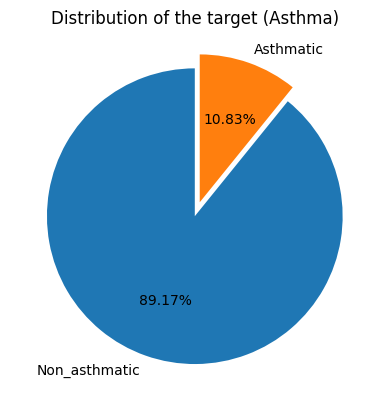

In [295]:
Asthmatic_percntage=brfss_2019_michigan['Current_Asthma'].value_counts(normalize=True).mul(100).rename(index={0:'Non_asthmatic',1:'Asthmatic'})
plt.pie(Asthmatic_percntage,labels=Asthmatic_percntage.index,autopct='%.2f%%',explode=(0,.1),startangle=90)
plt.title('Distribution of the target (Asthma)')



## <span style="color:blue">After ploting the distribution of the target seems that data suffers from class imbalance</span>
- <span style="color:blue">so our purpose to imporove model predictability using different methods </span> -- Random oversampling ,  oversampling with SMOTE, ADASYN, undersampling with TOMEK links, and Oversampling with SMOTE then undersampling with TOMEK Links  

In [296]:
# spliting the data into two parts train and test split 
# Now i will drop person final weight and state 
brfss_2019_michigan.drop(['State','Survey_Weight'],axis=1,inplace=True)




In [297]:
from asthma_improved_notebook import run_improved_analysis


IMPROVED ASTHMA MODEL ANALYSIS

1. ADVANCED RESAMPLING COMPARISON (with scaling and advanced methods)
--------------------------------------------------------------------------------
               Resampling                   Model  ...      F1  ROC_AUC
0           No Resampling     Logistic Regression  ...  0.3009   0.6993
1           No Resampling           Random Forest  ...  0.2021   0.6947
2           No Resampling       Gradient Boosting  ...  0.1114   0.6659
3           No Resampling  Support Vector Machine  ...  0.2924   0.6836
4           No Resampling     K-Nearest Neighbors  ...  0.0849   0.6284
5    Random Over-Sampling     Logistic Regression  ...  0.3043   0.6988
6    Random Over-Sampling           Random Forest  ...  0.2016   0.6806
7    Random Over-Sampling       Gradient Boosting  ...  0.2738   0.6375
8    Random Over-Sampling  Support Vector Machine  ...  0.2574   0.6639
9    Random Over-Sampling     K-Nearest Neighbors  ...  0.2422   0.6176
10  Random Under-Sampling

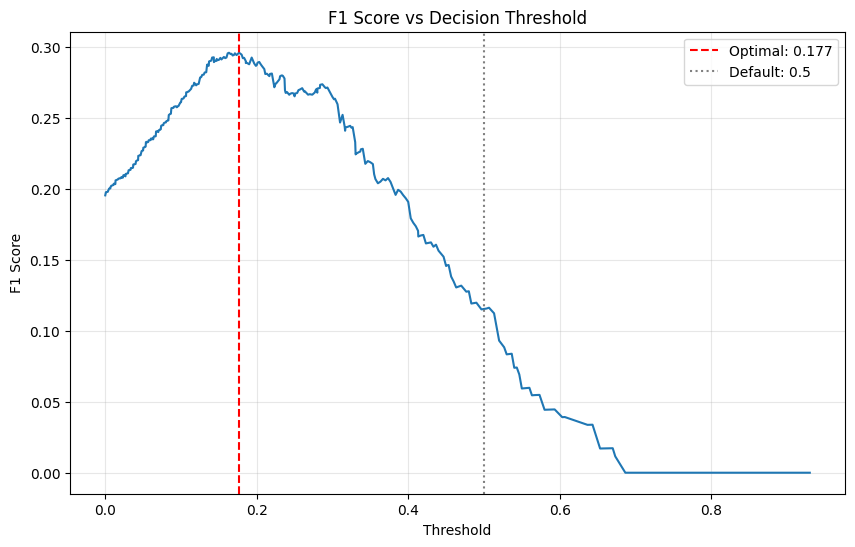


5. FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------------------------------------


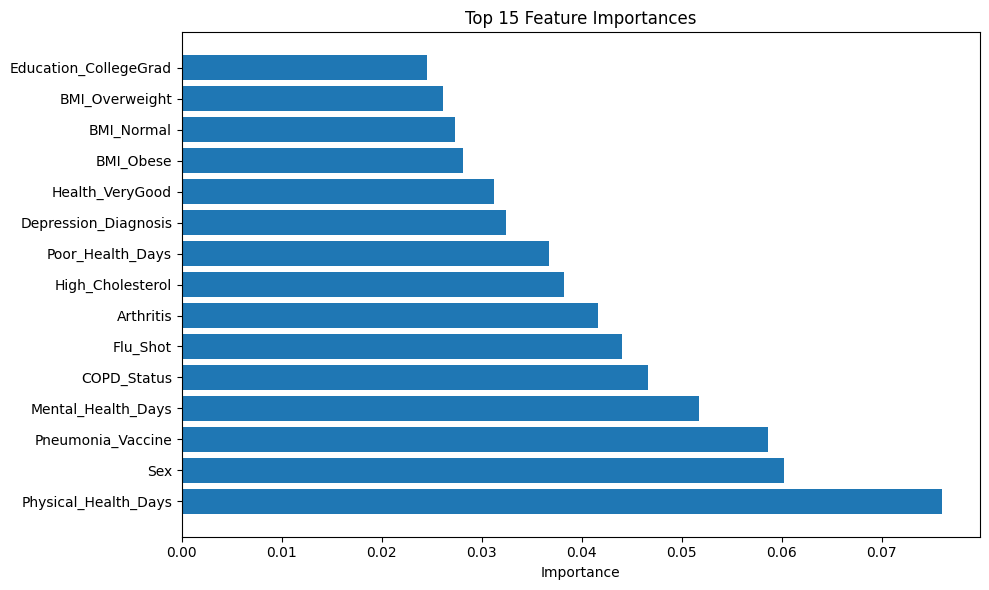

                  Feature  Importance
0    Physical_Health_Days    0.076025
1                     Sex    0.060241
2       Pneumonia_Vaccine    0.058650
3      Mental_Health_Days    0.051717
4             COPD_Status    0.046621
5                Flu_Shot    0.044053
6               Arthritis    0.041653
7        High_Cholesterol    0.038244
8        Poor_Health_Days    0.036721
9    Depression_Diagnosis    0.032370
10        Health_VeryGood    0.031228
11              BMI_Obese    0.028161
12             BMI_Normal    0.027315
13         BMI_Overweight    0.026085
14  Education_CollegeGrad    0.024558

Analysis complete! Results saved to CSV files.


{'advanced_resampling':                Resampling                   Model  ...      F1  ROC_AUC
 0           No Resampling     Logistic Regression  ...  0.3009   0.6993
 1           No Resampling           Random Forest  ...  0.2021   0.6947
 2           No Resampling       Gradient Boosting  ...  0.1114   0.6659
 3           No Resampling  Support Vector Machine  ...  0.2924   0.6836
 4           No Resampling     K-Nearest Neighbors  ...  0.0849   0.6284
 5    Random Over-Sampling     Logistic Regression  ...  0.3043   0.6988
 6    Random Over-Sampling           Random Forest  ...  0.2016   0.6806
 7    Random Over-Sampling       Gradient Boosting  ...  0.2738   0.6375
 8    Random Over-Sampling  Support Vector Machine  ...  0.2574   0.6639
 9    Random Over-Sampling     K-Nearest Neighbors  ...  0.2422   0.6176
 10  Random Under-Sampling     Logistic Regression  ...  0.2927   0.7043
 11  Random Under-Sampling           Random Forest  ...  0.3009   0.7207
 12  Random Under-Sampling  

In [298]:
run_improved_analysis(brfss_2019_michigan)

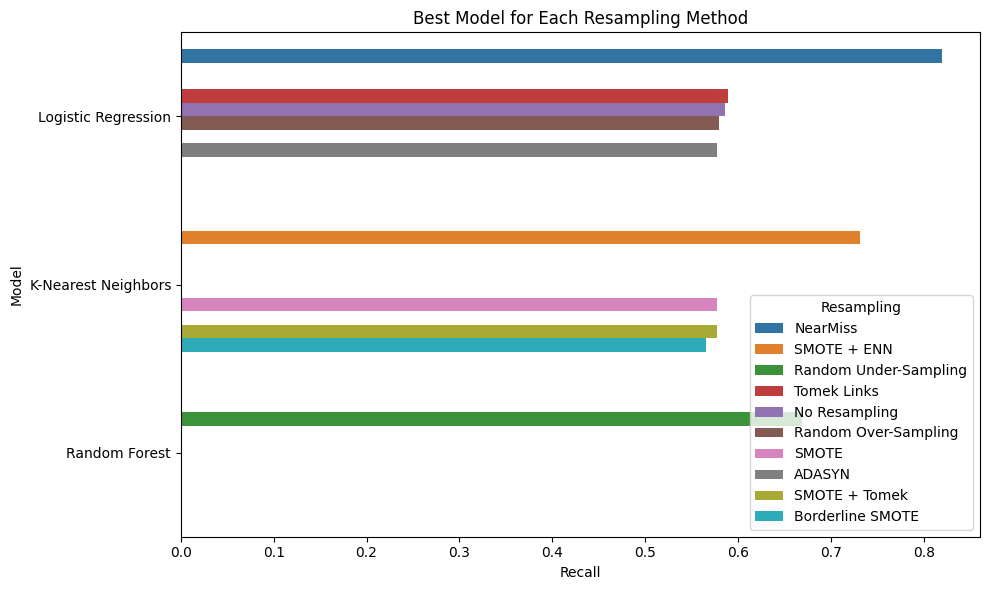

In [299]:
advanced_resampling=pd.read_csv('asthma_advanced_resampling.csv')
best = (
    advanced_resampling
    .loc[
        advanced_resampling.groupby('Resampling')['Recall'].idxmax()
    ]
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=best.sort_values('Recall', ascending=False),
    x='Recall',
    y='Model',
    hue='Resampling'
)

plt.title('Best Model for Each Resampling Method')
plt.tight_layout()


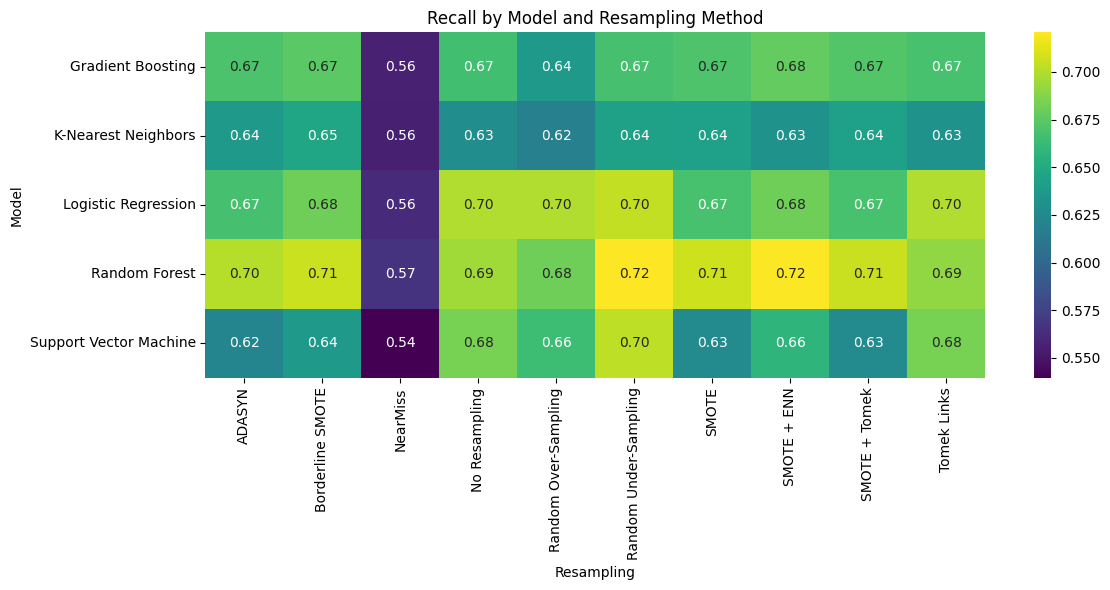

In [300]:
pivot = advanced_resampling.pivot(
    index='Model',
    columns='Resampling',
    values='ROC_AUC'
)

plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='viridis'
)

plt.title('Recall by Model and Resampling Method')
plt.tight_layout()
plt.show()

In [301]:
asthma_weight=pd.read_csv('asthma_class_weights.csv')
asthma_weight

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (Balanced),0.7055,0.2025,0.5858,0.3009,0.6993
1,Random Forest (Balanced),0.8896,0.2308,0.0089,0.0171,0.7072
2,SVM (Balanced),0.7878,0.2287,0.4053,0.2924,0.6836


In [302]:
pd.read_csv('asthma_cross_validation.csv')

,Model,F1_Mean,F1_Std,Recall_Mean,Recall_Std,ROC_AUC_Mean,ROC_AUC_Std
0,Logistic Regression,0.2998,0.0069,0.6122,0.0352,0.7071,0.0135
1,Random Forest,0.1096,0.0297,0.0639,0.0176,0.6861,0.0223
2,Gradient Boosting,0.1322,0.0314,0.0772,0.0190,0.7003,0.0252
